In [1]:
from langgraph.graph import StateGraph , END , START
from typing import TypedDict

In [18]:
class flow_state(TypedDict):
    runs : int
    bolls : int
    four : int
    six : int

    strike_rate : float
    bpd : float
    boundry_percentage : float
    summary : str


In [19]:
def c_strike_rate(state:flow_state):
    runs = state["runs"]
    bolls = state["bolls"]
   
    strike_rate = (runs/bolls)*100

    return {"strike_rate":strike_rate}


In [20]:
def c_bpd(state:flow_state):
    bolls = state["bolls"]
    four = state["four"]
    six = state["six"]
    
    bpd = bolls/(four + six)

    return {"bpd":bpd}


In [21]:
def c_boundry_percentage(state:flow_state):
    runs = state["runs"]
    four = state["four"]
    six = state["six"]
    
    boundry_percentage = ((four*4)+(six*6))/runs

    return {"boundry_percentage":boundry_percentage}

In [34]:
def c_summary(state:flow_state):
    summary = f"""
Given batsman's stike rate is {state['strike_rate']} \n
bpd is {state["bpd"]}\n
and boundry precentage is {state["boundry_percentage"]} """
    state["summary"] = summary
    return state

In [35]:
graph =StateGraph(flow_state)

graph.add_node("c_strike_rate",c_strike_rate)
graph.add_node("c_bpd",c_bpd)
graph.add_node("c_boundry_percentage",c_boundry_percentage)
graph.add_node("c_summary",c_summary)

graph.add_edge(START,"c_strike_rate")
graph.add_edge(START,"c_bpd")
graph.add_edge(START,"c_boundry_percentage")
graph.add_edge("c_boundry_percentage","c_summary")
graph.add_edge("c_bpd","c_summary")
graph.add_edge("c_strike_rate","c_summary")
graph.add_edge("c_summary",END)

workflow = graph.compile()

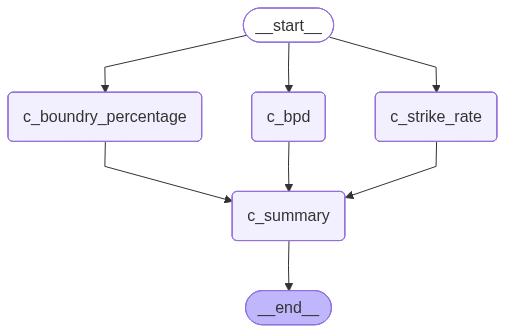

In [36]:
workflow

In [37]:
intial_state = {
    'runs': 100,
    'bolls': 50,
    'four': 6,
    'six': 4
}

workflow.invoke(intial_state)

{'runs': 100,
 'bolls': 50,
 'four': 6,
 'six': 4,
 'strike_rate': 200.0,
 'bpd': 5.0,
 'boundry_percentage': 0.48,
 'summary': "\nGiven batsman's stike rate is 200.0 \n\nbpd is 5.0\n\nand boundry precentage is 0.48 "}